# 02 – EDA: Student Depression Dataset

Utforskande dataanalys inför modellering. Bygger på det **rensade och kodade** datasetet från
`01_Dataforberedelse.ipynb` (`student_depression_clean.csv`) - saknade värden, smutsig data och
irrelevanta kolumner är redan hanterade där.

Mål: förstå distributionerna och vilka variabler som verkar hänga ihop med `Depression`.

In [1]:
import pandas as pd                # DataFrames - tabellhantering, motsvarar ett kalkylark i kod
import numpy as np                 # numeriska beräkningar (används sällan direkt här, men standard att ha med)
import matplotlib.pyplot as plt    # grundläggande plottbibliotek
import seaborn as sns              # statistisk visualisering byggt ovanpå matplotlib, snyggare defaultstil

sns.set_theme(style="whitegrid")          # sätter en global, ljus rutnätsstil på alla plottar nedan
pd.set_option("display.max_columns", None)  # visa ALLA kolumner i output, inte trunkerat med "..."

## 1. Ladda in datan

In [2]:
df = pd.read_csv("student_depression_clean.csv")  # ladda det REDAN RENSADE datasetet, inte rådatan
print(df.shape)   # (antal rader, antal kolumner)
df.head()          # notera att Gender, Sleep Duration, Dietary Habits m.fl. redan är siffror - se kodningsnyckeln nedan

(27842, 13)


,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,Visakhapatnam,5.0,8.97,2.0,2,3,1,3.0,1.0,0,1
1,0,24.0,Bangalore,2.0,5.90,5.0,2,2,0,3.0,2.0,1,0
2,1,31.0,Srinagar,3.0,7.03,5.0,1,3,0,9.0,1.0,1,0
3,0,28.0,Varanasi,3.0,5.59,2.0,3,2,1,4.0,5.0,1,1
4,0,25.0,Jaipur,4.0,8.13,3.0,2,2,1,1.0,1.0,0,0


### Kodningsnyckel

Kategoriska variabler kodades om till siffror i `01_Dataforberedelse.ipynb`. Referens för att tolka
värdena i resten av denna notebook (t.ex. i korstabellerna nedan):

| Kolumn | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| `Gender` | Female | Male | | | |
| `Have you ever had suicidal thoughts ?` | No | Yes | | | |
| `Family History of Mental Illness` | No | Yes | | | |
| `Dietary Habits` | | Unhealthy | Moderate | Healthy | |
| `Sleep Duration` | | Less than 5h | 5-6h | 7-8h | More than 8h |

`City` lämnades som text (för hög kardinalitet för enkel kodning i detta steg).

In [3]:
# Visar datatyp per kolumn (int/float/object) samt hur många icke-tomma värden varje
# kolumn har. Bra första koll på var det finns saknade värden och om typerna stämmer
# (t.ex. att en siffra inte råkat bli inläst som text).
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27842 entries, 0 to 27841
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27842 non-null  int64  
 1   Age                                    27842 non-null  float64
 2   City                                   27842 non-null  str    
 3   Academic Pressure                      27842 non-null  float64
 4   CGPA                                   27842 non-null  float64
 5   Study Satisfaction                     27842 non-null  float64
 6   Sleep Duration                         27842 non-null  int64  
 7   Dietary Habits                         27842 non-null  int64  
 8   Have you ever had suicidal thoughts ?  27842 non-null  int64  
 9   Work/Study Hours                       27842 non-null  float64
 10  Financial Stress                       27842 non-null  float64
 11  Family Histor

## 2. Saknade värden & extremvärden

In [4]:
missing = df.isnull().sum()      # räknar antal saknade (NaN) värden per kolumn
missing[missing > 0]              # sanity check - bör vara TOM eftersom 01_Dataforberedelse redan hanterat detta

Series([], dtype: int64)

In [5]:
# Statistiska mått (medelvärde, std, min, kvartiler, max) för alla NUMERISKA kolumner.
# Bra för att upptäcka orimliga min/max-värden (extremvärden/outliers), t.ex. en Age på 5 eller 90.
df.describe(include="number")

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000
mean,0.557252,25.820667,3.141656,7.656027,2.944149,2.399253,1.904605,0.632821,7.158286,3.140435,0.484161,0.585554
std,0.496720,4.906187,1.381729,1.470880,1.360890,1.126845,0.796905,0.482045,3.707158,1.437076,0.499758,0.492635
min,0.000000,18.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,21.000000,2.000000,6.290000,2.000000,1.000000,1.000000,0.000000,4.000000,2.000000,0.000000,0.000000
50%,1.000000,25.000000,3.000000,7.770000,3.000000,2.000000,2.000000,1.000000,8.000000,3.000000,0.000000,1.000000
75%,1.000000,30.000000,4.000000,8.920000,4.000000,3.000000,3.000000,1.000000,10.000000,4.000000,1.000000,1.000000
max,1.000000,59.000000,5.000000,10.000000,5.000000,4.000000,3.000000,1.000000,12.000000,5.000000,1.000000,1.000000


In [6]:
# Samma sak, fast för TEXT-kolumner: visar antal ifyllda värden, hur många unika
# kategorier, vanligaste värdet ("top") och hur många gånger det förekommer ("freq").
df.describe(include="object")

/var/folders/7b/kbzrw4d15z3dj4gwlkzpj39w0000gn/T/ipykernel_44049/3547002733.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,City
count,27842
unique,30
top,Kalyan
freq,1569


## 3. Kolumner som redan hanterats

`Profession`, `Work Pressure`, `Job Satisfaction`, `Degree` och `id` var mest tomma/irrelevanta
(majoriteten i datasetet är heltidsstudenter) och droppades redan i `01_Dataforberedelse.ipynb`.

## 4. Målvariabeln: balans

In [7]:
# normalize=True gör att vi får ANDELAR (0-1) istället för antal - dvs hur stor
# procentandel av studenterna som har Depression=0 respektive Depression=1.
# Avgör om målvariabeln är balanserad eller skev (viktigt inför modellval senare).
df["Depression"].value_counts(normalize=True)

Depression
1    0.585554
0    0.414446
Name: proportion, dtype: float64

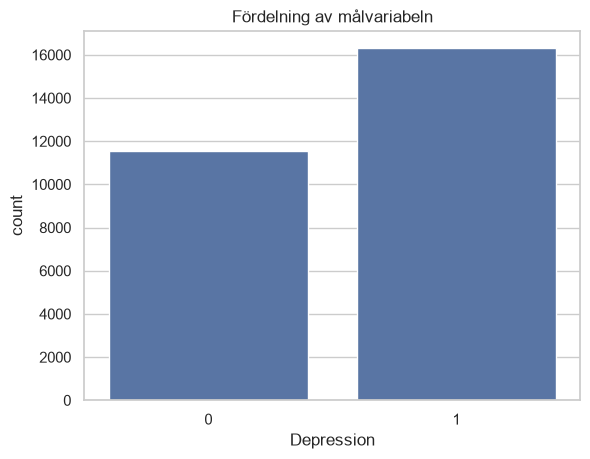

In [8]:
# Samma information som ovan, fast som stapeldiagram - lättare att ta in visuellt.
sns.countplot(data=df, x="Depression")
plt.title("Fördelning av målvariabeln")
plt.show()

## 5. Hypoteser mot Depression

Sömn, akademisk press, ekonomisk stress, familjehistorik m.fl.

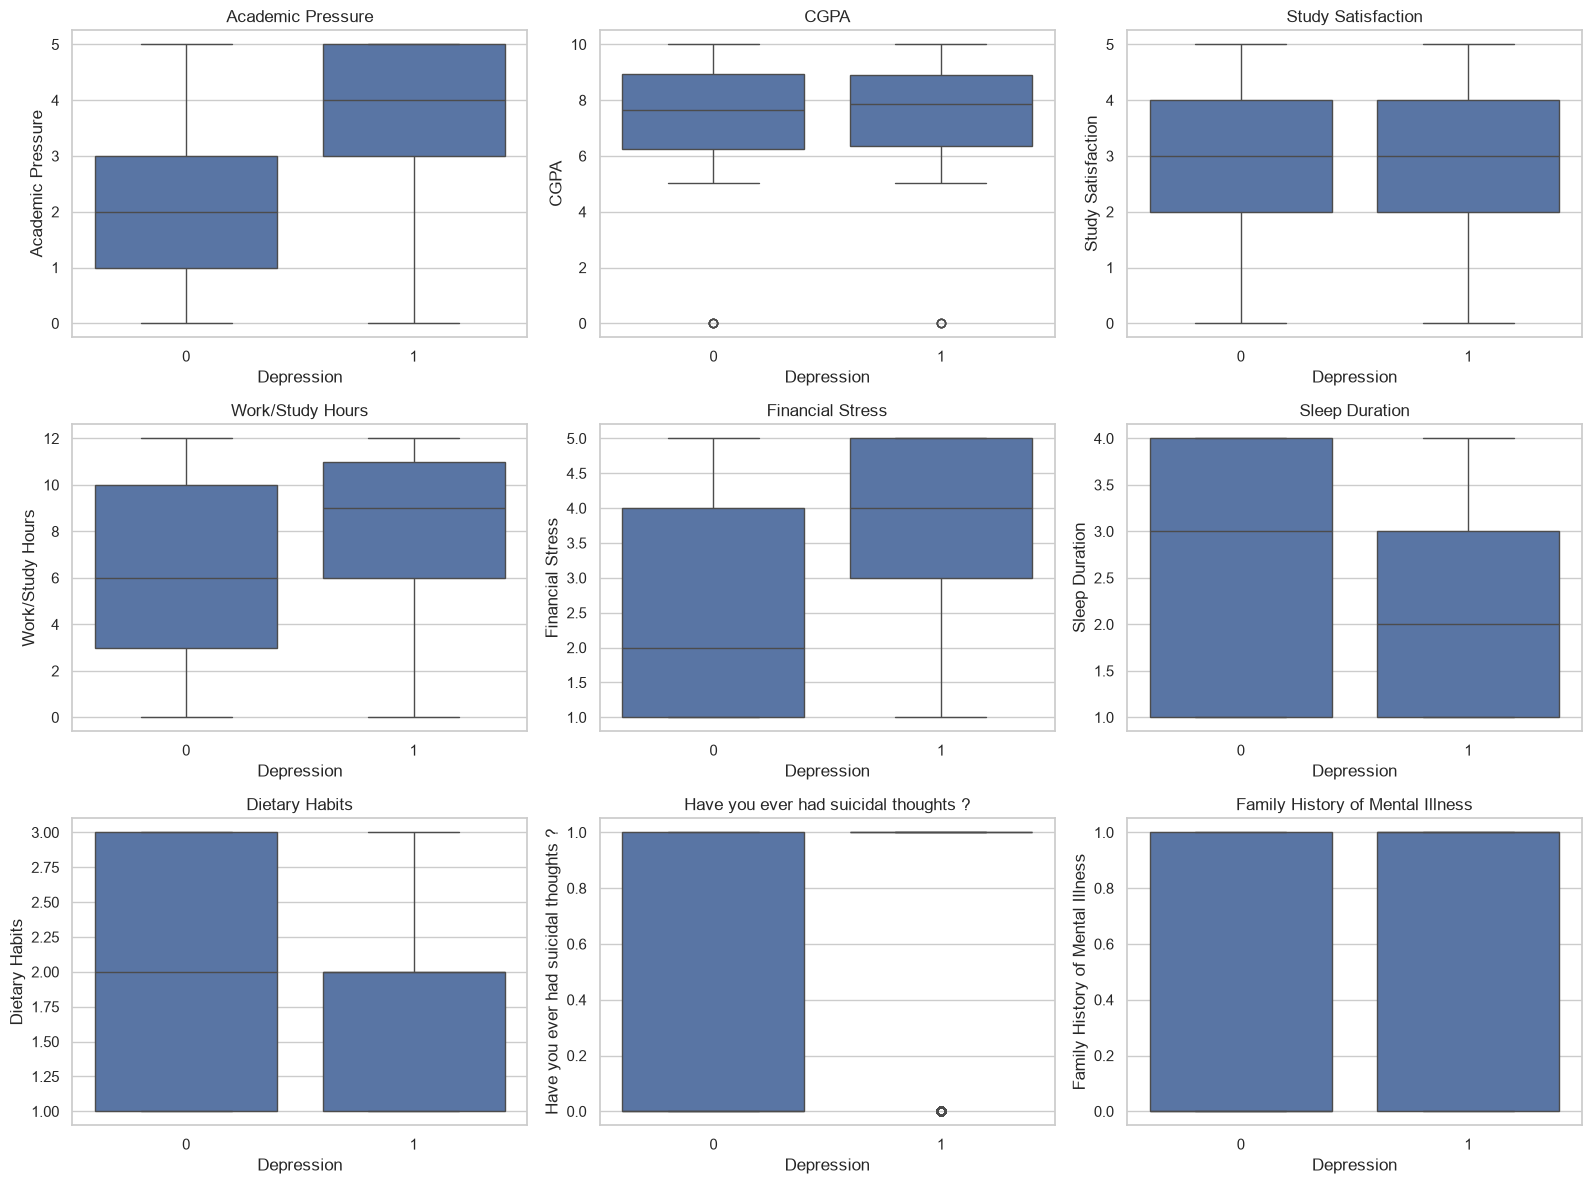

In [9]:
numeric_cols = ["Academic Pressure", "CGPA", "Study Satisfaction",
                 "Work/Study Hours", "Financial Stress",
                 "Sleep Duration", "Dietary Habits",
                 "Have you ever had suicidal thoughts ?",
                 "Family History of Mental Illness"]  # nu numeriska tack vare kodningen i 01

# Boxplot per numerisk/kodad variabel, uppdelat på Depression (0 vs 1).
# Boxen = 25:e till 75:e percentilen (IQR), strecket i mitten = median,
# "morrhåren" = normal spridning, enskilda punkter utanför = extremvärden (outliers).
# Om boxarna ligger tydligt förskjutna mellan 0 och 1 tyder det på ett samband med Depression.
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=df, x="Depression", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [10]:
# Korstabell: för varje sömnkategori (raden, se kodningsnyckeln för vad 1-4 betyder), hur stor
# ANDEL har Depression=0 vs Depression=1? normalize="index" gör att varje RAD summerar till 1.0
# (100%) - vi jämför alltså andelar mellan grupper istället för råa antal.
pd.crosstab(df["Sleep Duration"], df["Depression"], normalize="index")

Depression,0,1
Sleep Duration,,
1,0.354707,0.645293
2,0.431465,0.568535
3,0.404746,0.595254
4,0.490894,0.509106


In [11]:
# Samma logik som ovan, nu för familjehistorik av psykisk ohälsa (0=No, 1=Yes, se kodningsnyckeln).
pd.crosstab(df["Family History of Mental Illness"], df["Depression"], normalize="index")

Depression,0,1
Family History of Mental Illness,,
0,0.439911,0.560089
1,0.387315,0.612685


In [12]:
# Samma logik, nu för självmordstankar (0=No, 1=Yes) - den KÄNSLIGA variabeln. Vi tittar bara på
# gruppnivå (andelar), aldrig på enskilda individer, i enlighet med projektets riktlinjer.
pd.crosstab(df["Have you ever had suicidal thoughts ?"], df["Depression"], normalize="index")

Depression,0,1
Have you ever had suicidal thoughts ?,,
0,0.767876,0.232124
1,0.209376,0.790624


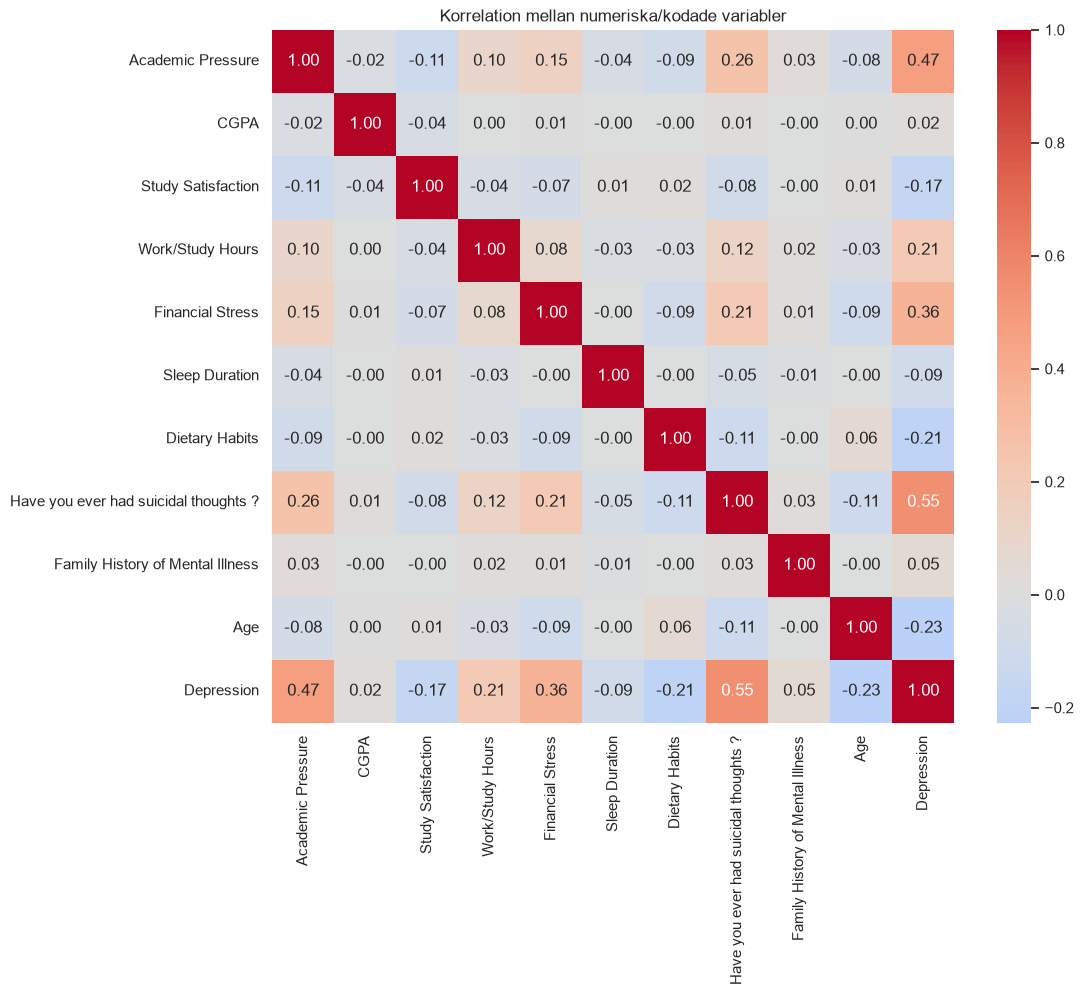

In [13]:
# Pearson-korrelation mellan de numeriska/kodade variablerna (linjärt samband, mellan -1 och +1).
# Nära +1 = starkt positivt samband, nära -1 = starkt negativt, nära 0 = svagt/inget samband.
# OBS: fångar bara LINJÄRA samband - ett svagt värde utesluter inte ett icke-linjärt samband.
corr = df[numeric_cols + ["Age", "Depression"]].corr(numeric_only=True)
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korrelation mellan numeriska/kodade variabler")
plt.show()

In [14]:
# Samma korrelationer som i heatmapen ovan, men rangordnade efter absolutbelopp
# (abs) - dvs starkast samband (positivt ELLER negativt) högst upp. Lättare att
# snabbt se vilka variabler som är viktigast utan att behöva läsa av en bild.
corr["Depression"].drop("Depression").sort_values(key=abs, ascending=False)

Have you ever had suicidal thoughts ?    0.546494
Academic Pressure                        0.474886
Financial Stress                         0.363238
Age                                     -0.226872
Work/Study Hours                         0.208779
Dietary Habits                          -0.206934
Study Satisfaction                      -0.168199
Sleep Duration                          -0.087221
Family History of Mental Illness         0.053357
CGPA                                     0.021508
Name: Depression, dtype: float64

In [15]:
# Kostvanor mot Depression (1=Unhealthy, 2=Moderate, 3=Healthy, se kodningsnyckeln).
pd.crosstab(df["Dietary Habits"], df["Depression"], normalize="index")

Depression,0,1
Dietary Habits,,
1,0.292472,0.707528
2,0.439645,0.560355
3,0.546145,0.453855


In [16]:
# Kön mot Depression (0=Female, 1=Male, se kodningsnyckeln) - kollar om det finns könsskillnad.
pd.crosstab(df["Gender"], df["Depression"], normalize="index")

Depression,0,1
Gender,,
0,0.415511,0.584489
1,0.413600,0.586400


## 6. Anteckningar / slutsatser

Rangordnat efter absolutbeloppet av korrelationen med `Depression` (nu att alla kategoriska
variabler är kodade som siffror ryms de i samma korrelationslista - se cellen ovan):

**Starkast koppling**
- **Suicidal thoughts** – korrelation ≈ 0.55, starkast av alla variabler. Bekräftas av korstabellen: ~79% depression bland de som svarat "Yes", mot ~23% bland "No". Känslig variabel – analyseras endast på gruppnivå.
- **Academic Pressure** – korrelation ≈ 0.47.
- **Financial Stress** – korrelation ≈ 0.36.

**Måttlig koppling**
- **Age** – korrelation ≈ -0.23 (yngre studenter tenderar till högre andel depression).
- **Work/Study Hours** – korrelation ≈ 0.21.
- **Dietary Habits** – korrelation ≈ -0.21 (kodat 1=Unhealthy...3=Healthy, så negativt tecken betyder: bättre kost → mindre depression). Korstabellen visar samma sak tydligare: Healthy ~45% → Moderate ~56% → Unhealthy ~71% depression.
- **Study Satisfaction** – korrelation ≈ -0.17.

**Svag/ingen koppling**
- **Sleep Duration** – korrelation ≈ -0.09, svagare än väntat. Anledning: sambandet är inte perfekt linjärt (korstabellen visar att "More than 8 hours" INTE har lägst andel depression, vilket bryter mot antagandet om en rak ordinal skala) - ett bra exempel på varför korrelation kan underskatta ett samband som ändå syns tydligt i en korstabell.
- **Family History of Mental Illness** – korrelation ≈ 0.05, svagare i korrelationsmåttet än vad skillnaden i korstabellen (~61% vs ~56%) antyder.
- **CGPA** – korrelation ≈ 0.02, i praktiken obefintlig koppling.
- **Gender** – nästan ingen skillnad mellan grupperna (se separat korstabell) – ser könsneutralt ut i denna data.

**Implikationer för nästa steg:**
- `Depression` är rimligt balanserad (58.6% / 41.4% efter dataförberedelsen) → fungerar bra som binär målvariabel utan att behöva balanseringstekniker i första försöket.
- CGPA och Gender är kandidater att nedprioritera vid feature-val.
- Suicidal thoughts är så starkt kopplad att den riskerar att dominera/läcka information - överväg att träna modeller både MED och UTAN denna variabel för att få en mer meningsfull jämförelse (se diskussion om detta i projektplaneringen).
- Sleep Duration-exemplet är en påminnelse om att inte bara lita på korrelationstal - icke-linjära modeller (Random Forest, neurala nätverk) kan fånga mönster som en enkel linjär korrelation missar.